In [1]:
!rm -rf InkubaLM-Challenge
!git clone https://github.com/melissafasol/InkubaLM-Challenge.git
%cd InkubaLM-Challenge

Cloning into 'InkubaLM-Challenge'...
remote: Enumerating objects: 347, done.
remote: Counting objects: 100% (145/145), done.
remote: Compressing objects: 100% (120/120), done.
remote: Total 347 (delta 91), reused 51 (delta 23), pack-reused 202 (from 1)
Receiving objects: 100% (347/347), 1.19 MiB | 3.36 MiB/s, done.
Resolving deltas: 100% (218/218), done.
/content/InkubaLM-Challenge


In [2]:
!git checkout refactor-src-structure
!git pull

Branch 'refactor-src-structure' set up to track remote branch 'refactor-src-structure' from 'origin'.
Switched to a new branch 'refactor-src-structure'
Already up to date.


In [3]:
!pip install datasets
!pip install transformers datasets peft trl accelerate bitsandbytes

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 491.2/491.2 kB 9.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.3/116.3 kB 8.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 183.9/183.9 kB 10.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 143.5/143.5 kB 8.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 194.8/194.8 kB 16.6 MB/s eta 0:00:00
  Attempting uninstall: fsspec
    Found existing installation: fsspec 2025.3.2
    Uninstalling fsspec-2025.3.2:
      Successfully uninstalled fsspec-2025.3.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gcsfs 2025.3.2 requires fsspec==2025.3.2, but you have fsspec 2024.12.0 which is incompatible.
torch 2.6.0+cu124 requires nvidia-cublas-cu12==12.4.5.8; platform_system == "Linux" and platform_machine == "x86_64", but you have nvidia-cublas-cu12 12.5.3.2 which is

In [4]:
# Cell 1: Install dependencies
!pip install -q transformers accelerate peft datasets bitsandbytes trl

# Cell 2: Imports and setup
from transformers import AutoModelForCausalLM, AutoTokenizer, pipeline
from datasets import load_dataset, Dataset
import pandas as pd
import torch
from tqdm import tqdm
from transformers import AutoTokenizer, Gemma3ForConditionalGeneration

# Set device
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

Using device: cuda


In [5]:
import sys
sys.path.append("..")  # Add parent directory to the path

import os
from typing import List
from pathlib import Path
import numpy as np

# DO NOT EDIT
# create submission file
import pandas as pd
from huggingface_hub import login
from transformers import (
    AutoTokenizer,
)

from utils import (
    model_function,
    eval
    )

from src import (
    data_utils,
    model_utils,
    inference,
    prompts,
    evaluation,
    data_augment
    )

import torch
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig
from peft import LoraConfig, get_peft_model, PeftModel
from datasets import load_dataset, concatenate_datasets, Dataset, Value, DatasetDict

from trl import SFTConfig, SFTTrainer, DataCollatorForCompletionOnlyLM
from peft import PeftModel, PeftConfig
from sklearn.model_selection import train_test_split

In [6]:
#os.environ["TOKENIZERS_PARALLELISM"] = "false"

from huggingface_hub import login

try:
    from google.colab import userdata

    # Note: `userdata.get` is a Colab API. If you're not using Colab, set the env
    # vars as appropriate for your system.
    # userdata.get("HF_TOKEN") indicates that the name of the token in the Colab env is HF_TOKEN
    os.environ["hf_token_2"] = userdata.get("hf_token_2")
except:
    os.environ["hf_token_2"] = "----"

login(token=os.environ["hf_token_2"])

token = os.environ["hf_token_2"]
if token == "----":
    print("⚠️ Warning: No Hugging Face token found. Some models may not load.")
else:
    login(token=token)

In [7]:
hf_token_2 = '....' # paste your token here
os.environ["HF_TOKEN"] = hf_token_2


In [8]:
from huggingface_hub import login
login(token=hf_token_2)  # Force login using this token


Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


In [9]:
import os
import json

file_path = '/content/'

# Infer language from ID or langs field
def infer_lang(example):
    if example["task"] == "translation":
        return example.get("langs", "eng-swa")
    elif "swa" in example["ID"]:
        return "swahili"
    elif "hau" in example["ID"]:
        return "hausa"
    else:
        return "unknown"

# Build prompt without <lang> tokens
def format_prompt(ex):
    instruction = ex.get("instruction", "").strip()
    input_text = ex.get("input", "").strip()
    return f"{instruction}\n{input_text}".strip() if input_text else instruction

# Load and transform data
input_files = [
    os.path.join(file_path, "gemma_sentiment_soft_labels.jsonl"),
    os.path.join(file_path, "gemma_xnli_soft_labels_mc.jsonl"),
    os.path.join(file_path, "gemma_mt_distilled.jsonl"),
]

all_tasks = []
for fname in input_files:
    with open(fname) as f:
        for line in f:
            ex = json.loads(line)
            ex["lang"] = infer_lang(ex)
            ex["prompt"] = format_prompt(ex)
            all_tasks.append(ex)

# Save to final multitask JSONL
output_path = os.path.join(file_path, "multitask_distill.jsonl")
with open(output_path, "w") as f:
    for row in all_tasks:
        f.write(json.dumps(row) + "\n")

print(f"✅ Saved multitask distillation dataset to: {output_path}")


✅ Saved multitask distillation dataset to: /content/multitask_distill.jsonl


In [11]:
from datasets import Dataset

dataset = Dataset.from_list(all_tasks)


In [58]:
sentiment_xnli_raw = all_tasks[0:600]
sentiment_xnli_raw[0]

{'ID': 'ID_f3c74c7b_sentiment_test__hausa',
 'task': 'sentiment',
 'instruction': "Your task is to do sentiment analysis. Your output must be one word: positive, negative, or neutral. Don't output any explanation.",
 'input': '@user ynxu fha da kanada kudi shikenan duk kayan nan zasu iya zama naka no🧢',
 'output': 'negative',
 'soft_label': {'positive': 0.0, 'neutral': 6e-05, 'negative': 0.99844},
 'lang': 'hausa',
 'prompt': "Your task is to do sentiment analysis. Your output must be one word: positive, negative, or neutral. Don't output any explanation.\n@user ynxu fha da kanada kudi shikenan duk kayan nan zasu iya zama naka no🧢"}

In [17]:
sentiment_xnli_raw[599]

{'ID': 'ID_31eb3181_test__afrixnli_swa',
 'task': 'xnli',
 'instruction': 'Premise: Katika mbinu ya kikundi, aian aya kikundi ya kazi , hupewa asilimia ya alama ya gharama, ili kupata kiwango cha wastani.\nClaim: Kikundi cha msingi ni zaidi ya gharama.\nIs the claim entailed by the premise? Answer:',
 'input': '',
 'output': 'false',
 'soft_label': {'true': 0.00247, 'neither': 1e-05, 'false': 0.99752},
 'lang': 'swahili',
 'prompt': 'Premise: Katika mbinu ya kikundi, aian aya kikundi ya kazi , hupewa asilimia ya alama ya gharama, ili kupata kiwango cha wastani.\nClaim: Kikundi cha msingi ni zaidi ya gharama.\nIs the claim entailed by the premise? Answer:'}

In [11]:
mt_raw = all_tasks[600:900]

In [18]:
mt_raw[0]

{'ID': 'ID_290c7da3_test__mt_eng-hau',
 'task': 'translation',
 'instruction': "Your task is to do translation from English to Hausa. Your output must be the translation only. Don't output any explanation.",
 'input': "here's what you can expect during your visit.",
 'output': 'Lokacin zaicewa za ka samu manyi.',
 'lang': 'eng-swa',
 'prompt': "Your task is to do translation from English to Hausa. Your output must be the translation only. Don't output any explanation.\nhere's what you can expect during your visit."}

In [63]:
import os
import torch
import torch.nn.functional as F
from transformers import (
    AutoModelForCausalLM,
    AutoTokenizer,
    BitsAndBytesConfig,
    TrainingArguments,
    Trainer
)
from peft import LoraConfig, get_peft_model
from datasets import Dataset as HFDataset
from torch.utils.data import Dataset as TorchDataset

# ---------------------------
# 1. Label map
# ---------------------------
LABEL_MAP = {
    "sentiment": ["positive", "negative", "neutral"],
    "xnli": ["true", "false", "neither"]
}

# ---------------------------
# 2. Convert soft_label dicts to vectors
# ---------------------------
def preprocess_soft_labels(examples):
    processed = []
    for i, ex in enumerate(examples):
        task = ex.get("task")
        label_order = LABEL_MAP.get(task, [])
        if not label_order:
            continue

        soft_dict = ex.get("soft_label", {})
        label_vector = [float(soft_dict.get(label, 0.0) or 0.0) for label in label_order]

        if sum(label_vector) == 0:
            continue

        processed.append({
            "prompt": ex["prompt"].strip(),
            "soft_label": label_vector,
            "task": task  # include task for dynamic loss handling
        })
    return processed

# ---------------------------
# 3. Load Lelapa InkubaLM-0.4B with LoRA + 4-bit
# ---------------------------
def load_lora_model(model_name="lelapa/InkubaLM-0.4B"):
    bnb_config = BitsAndBytesConfig(
        load_in_4bit=True,
        bnb_4bit_use_double_quant=True,
        bnb_4bit_quant_type="nf4",
        bnb_4bit_compute_dtype=torch.bfloat16,
    )

    tokenizer = AutoTokenizer.from_pretrained(model_name, use_fast=True)
    if tokenizer.pad_token is None:
        tokenizer.pad_token = tokenizer.eos_token

    model = AutoModelForCausalLM.from_pretrained(
        model_name,
        quantization_config=bnb_config,
        device_map="auto"
    )

    lora_config = LoraConfig(
        r=8,
        lora_alpha=16,
        target_modules=["q_proj", "v_proj"],
        lora_dropout=0.05,
        bias="none",
        task_type="CAUSAL_LM"
    )

    model = get_peft_model(model, lora_config)
    model.print_trainable_parameters()
    return model, tokenizer

# ---------------------------
# 4. Custom Trainer with KL loss over class logits
# ---------------------------
class SoftDistillationTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        soft_labels = inputs.pop("soft_label")
        task_labels = inputs.pop("task")
        outputs = model(**inputs)
        logits = outputs.logits[:, -1, :]  # shape: [batch, vocab]

        task = task_labels[0]  # assumes same task in batch
        label_tokens = LABEL_MAP[task]
        label_token_ids = tokenizer.convert_tokens_to_ids(label_tokens)
        selected_logits = logits[:, label_token_ids]  # shape: [batch, num_labels]

        student_log_probs = F.log_softmax(selected_logits, dim=-1)
        loss = F.kl_div(student_log_probs, soft_labels.to(student_log_probs.device), reduction="batchmean")
        return (loss, outputs) if return_outputs else loss

# ---------------------------
# 5. Data collator
# ---------------------------
class SoftLabelDataCollator:
    def __init__(self, tokenizer):
        self.tokenizer = tokenizer

    def __call__(self, features):
        return {
            "input_ids": torch.stack([f["input_ids"] for f in features]),
            "attention_mask": torch.stack([f["attention_mask"] for f in features]),
            "soft_label": torch.stack([f["soft_label"] for f in features]),
            "task": [f["task"] for f in features],  # task names (as list of str)
        }

# ---------------------------
# 6. PyTorch dataset wrapper
# ---------------------------
class TorchSoftLabelDataset(TorchDataset):
    def __init__(self, dataset):
        self.dataset = dataset

    def __getitem__(self, idx):
        item = self.dataset[idx]
        return {
            "input_ids": torch.tensor(item["input_ids"], dtype=torch.long),
            "attention_mask": torch.tensor(item["attention_mask"], dtype=torch.long),
            "soft_label": torch.tensor(item["soft_label"], dtype=torch.float32),
            "task": item["task"]
        }

    def __len__(self):
        return len(self.dataset)

# ---------------------------
# 7. Training pipeline
# ---------------------------
def train_soft_distilled_lora_model(raw_data, model_name="lelapa/InkubaLM-0.4B"):
    print("✅ Preprocessing data...")
    processed = preprocess_soft_labels(raw_data)
    dataset = HFDataset.from_list(processed)

    print("✅ Loading model and tokenizer...")
    global tokenizer
    model, tokenizer = load_lora_model(model_name)

    def tokenize_function(example):
        encoding = tokenizer(
            example["prompt"],
            padding="max_length",
            truncation=True,
            max_length=512
        )
        return {
            "input_ids": encoding["input_ids"],
            "attention_mask": encoding["attention_mask"],
            "soft_label": example["soft_label"],
            "task": example["task"]
        }

    print("✅ Tokenizing dataset...")
    tokenized = dataset.map(tokenize_function, remove_columns=dataset.column_names)

    print("✅ Filtering out incomplete samples...")
    tokenized = tokenized.filter(
        lambda x: x.get("soft_label") is not None and all(v is not None for v in x["soft_label"])
    )
    print(f"✅ Final dataset size: {len(tokenized)} examples")

    print("✅ Wrapping in PyTorch dataset...")
    torch_dataset = TorchSoftLabelDataset(tokenized)

    training_args = TrainingArguments(
        output_dir= (os.path.join(output_path,"/soft_distill_inkuba_output")),
        per_device_train_batch_size=4,
        num_train_epochs=6,
        gradient_accumulation_steps=2,
        logging_steps=10,
        save_steps=50,
        logging_dir="./logs",
        report_to="none",
        evaluation_strategy="no",
        do_eval=False,
        remove_unused_columns=False,
    )

    print("🚀 Starting training...")
    trainer = SoftDistillationTrainer(
        model=model,
        args=training_args,
        train_dataset=torch_dataset,
        eval_dataset=None,
        data_collator=SoftLabelDataCollator(tokenizer),
    )

    trainer.train()

    model = model.merge_and_unload()
    model.save_pretrained(os.path.join(output_path,"/soft_distill_inkuba_output"))
    tokenizer.save_pretrained(os.path.join(output_path,"/soft_distill_inkuba_output"))

    return model, tokenizer

# ---------------------------
# 8. Run training
# ---------------------------
if __name__ == "__main__":
    train_soft_distilled_lora_model(sentiment_xnli_raw, model_name="lelapa/InkubaLM-0.4B")




✅ Preprocessing data...
✅ Loading model and tokenizer...
trainable params: 524,288 || all params: 664,684,544 || trainable%: 0.0789
✅ Tokenizing dataset...


Map:   0%|          | 0/600 [00:00<?, ? examples/s]

✅ Filtering out incomplete samples...


Filter:   0%|          | 0/600 [00:00<?, ? examples/s]

/usr/local/lib/python3.11/dist-packages/transformers/training_args.py:1611: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(
No label_names provided for model class `PeftModelForCausalLM`. Since `PeftModel` hides base models input arguments, if label_names is not given, label_names can't be set automatically within `Trainer`. Note that empty label_names list will be used instead.


✅ Final dataset size: 600 examples
✅ Wrapping in PyTorch dataset...
🚀 Starting training...


Step,Training Loss
10,1.566600
20,1.568300
30,1.496100
40,1.459300
50,1.305000
60,1.229700
70,1.348200
80,1.413000
90,1.112600
100,1.142400


/usr/local/lib/python3.11/dist-packages/peft/tuners/lora/bnb.py:355: UserWarning: Merge lora module to 4-bit linear may get different generations due to rounding errors.
  warnings.warn(


In [64]:
import os
output_path = "/content/drive/MyDrive/InkubaLM-Challenge/Output/distillation"
os.makedirs(output_path, exist_ok=True)

print(os.path.exists(output_path))  # Should return True
print(output_path)

True
/content/drive/MyDrive/InkubaLM-Challenge/Output/distillation


In [65]:
model = AutoModelForCausalLM.from_pretrained(os.path.join(output_path,"/soft_distill_inkuba_output")).to("cuda")
tokenizer = AutoTokenizer.from_pretrained("lelapa/InkubaLM-0.4B")
tokenizer.pad_token = tokenizer.eos_token  # Ensure padding is defined


`low_cpu_mem_usage` was None, now default to True since model is quantized.


In [76]:
sentiment_xnli_raw[0]

{'ID': 'ID_f3c74c7b_sentiment_test__hausa',
 'task': 'sentiment',
 'instruction': "Your task is to do sentiment analysis. Your output must be one word: positive, negative, or neutral. Don't output any explanation.",
 'input': '@user ynxu fha da kanada kudi shikenan duk kayan nan zasu iya zama naka no🧢',
 'output': 'negative',
 'soft_label': {'positive': 0.0, 'neutral': 6e-05, 'negative': 0.99844},
 'lang': 'hausa',
 'prompt': "Your task is to do sentiment analysis. Your output must be one word: positive, negative, or neutral. Don't output any explanation.\n@user ynxu fha da kanada kudi shikenan duk kayan nan zasu iya zama naka no🧢"}

In [72]:
import csv
from torch.nn.functional import log_softmax

def main(
    model,
    tokenizer,
    BASE_PROMPT,  # e.g., "{}\n### Response:"
    task_instruction,
    dataset,
    csv_file_path,
    custom_instruct=False,
    sample_size=4,
    max_new_tokens=100,
    seed=42,
    do_sample=True,
    min_length=None,
    use_cache=True,
    top_p=1.0,
    temperature=0.5,
    top_k=5,
    repetition_penalty=1.2,
    length_penalty=1,
    debug_labels=False,
    **kwargs,
):
    actual_model = getattr(model, "model", model)
    actual_model.eval()

    with open(csv_file_path, mode="w", newline="", encoding="utf-8") as file:
        writer = csv.writer(file)
        writer.writerow([
            "ID", "Instruction", "Input Text", "Response", "Log-Likelihoods", "Targets", "Task", "Langs",
        ])

        for i, item in enumerate(dataset):
            if i >= sample_size:
                break

            instruction = item["instruction"] if not custom_instruct else task_instruction
            input_text = item["inputs"]
            target_label = str(item.get("targets", ""))
            langs = item.get("langs", "")
            task = item.get("task", "xnli")
            identity = item["ID"]

            # Align formatting
            prompt_text = f"{instruction}\n{input_text}".strip()
            full_prompt = BASE_PROMPT.format(prompt_text)

            if task == "mmt":
                batch = tokenizer(full_prompt, return_tensors="pt").to(model.device)
                with torch.no_grad():
                    outputs = model.generate(
                        **batch,
                        max_new_tokens=max_new_tokens,
                        do_sample=do_sample,
                        top_p=top_p,
                        temperature=temperature,
                        min_length=min_length,
                        use_cache=use_cache,
                        top_k=top_k,
                        repetition_penalty=repetition_penalty,
                        length_penalty=length_penalty,
                        **kwargs,
                    )

                decoded_output = tokenizer.decode(outputs[0], skip_special_tokens=True)[len(full_prompt):].strip()
                response = decoded_output
                log_likelihoods = []

            else:
                if task == "xnli":
                    label_texts = ["Kweli", "Wala siyo", "Uongo"] if langs == "swa" else (
                        ["Gaskiya", "Tsaka-tsaki", "Karya"] if langs == "hau" else ["True", "Neither", "False"]
                    )
                else:  # sentiment
                    label_texts = ["Kyakkyawa", "Tsaka-tsaki", "Korau"] if langs == "hausa" else ["Chanya", "Wastani", "Hasi"]

                label_to_index = {label: idx for idx, label in enumerate(label_texts)}
                log_likelihoods = []

                for label in label_texts:
                    if debug_labels:
                        print(f"Label: {label} → Tokens: {tokenizer.tokenize(label)}")

                    prompt_tokens = tokenizer(full_prompt, return_tensors="pt").to(model.device)
                    label_tokens = tokenizer(label, return_tensors="pt").to(model.device)

                    input_ids = torch.cat([prompt_tokens["input_ids"], label_tokens["input_ids"][:, 1:]], dim=1)
                    attention_mask = torch.cat([prompt_tokens["attention_mask"], label_tokens["attention_mask"][:, 1:]], dim=1)

                    with torch.no_grad():
                        logits = model(input_ids=input_ids, attention_mask=attention_mask).logits
                        log_probs = log_softmax(logits, dim=-1)

                    label_token_ids = label_tokens["input_ids"][0][1:]  # remove BOS
                    label_start = input_ids.size(1) - label_token_ids.size(0)
                    token_log_probs = log_probs[0, label_start:label_start + len(label_token_ids)]
                    selected_log_probs = token_log_probs.gather(1, label_token_ids.unsqueeze(1)).squeeze(1)

                    normalized_log_prob = selected_log_probs.sum().item() / len(label_token_ids)
                    log_likelihoods.append(normalized_log_prob)

                best_index = int(torch.argmax(torch.tensor(log_likelihoods)))
                response = label_to_index[label_texts[best_index]]

            writer.writerow([
                identity,
                instruction,
                input_text,
                response,
                log_likelihoods,
                target_label,
                task,
                langs,
            ])




In [67]:
BASE_PROMPT = "{}\n### Response:"

sentiment_train = pd.read_parquet("hf://datasets/lelapa/SentimentTrain/data/train-00000-of-00001.parquet")
hau_sent_df = sentiment_train.loc[sentiment_train['langs'] == 'hausa']
swa_sent_df = sentiment_train.loc[sentiment_train['langs'] == 'swahili']
hau_sent_dset = Dataset.from_pandas(hau_sent_df)
swa_sent_dset = Dataset.from_pandas(swa_sent_df)

In [97]:
instruction = "Your task is to do sentiment analysis. Your output must be one word: positive, negative, or neutral. Don't output any explanation."
main(
    model=model,
    tokenizer=tokenizer,
    BASE_PROMPT="{}\n### Response:",  # Matches how it was trained!
    task_instruction= instruction,
    dataset=swa_sent_dset,
    csv_file_path= os.path.join(output_path,"swa_sent_prediction_dev.csv"),
    custom_instruct=False,
    sample_size=100,
    max_new_tokens=5,
    temperature=0.5,
    debug_labels=False
)

In [98]:
instruction = "Your task is to do sentiment analysis. Your output must be one word: positive, negative, or neutral. Don't output any explanation."
main(
    model=model,
    tokenizer=tokenizer,
    BASE_PROMPT="{}\n### Response:",  # Matches how it was trained!
    task_instruction= instruction,
    dataset=hau_sent_dset,
    csv_file_path= os.path.join(output_path,"hau_sent_prediction_dev.csv"),
    custom_instruct=False,
    sample_size=100,
    max_new_tokens=5,
    temperature=0.5,
    debug_labels=False
)

In [76]:

xnli_train = pd.read_parquet("hf://datasets/lelapa/XNLITrain/data/train-00000-of-00001.parquet")
hau_xnli_df = xnli_train.loc[xnli_train['langs'] == 'hau']
swa_xnli_df = xnli_train.loc[xnli_train['langs'] == 'swa']
hau_xnli_dset = Dataset.from_pandas(hau_xnli_df)
swa_xnli_dset = Dataset.from_pandas(swa_xnli_df)

In [83]:
swa_xnli_dset

Dataset({
    features: ['ID', 'langs', 'premise', 'inputs', 'instruction', 'targets', '__index_level_0__'],
    num_rows: 150
})

In [77]:
task_instruction = (
    "Your task is to determine if the claim is entailed by the premise. "
    "Your output must be one word: true, false, or neither. Don't output any explanation."
)

main(
    model=model,
    tokenizer=tokenizer,
    BASE_PROMPT="{}\n### Response:",  # Matches how it was trained!
    task_instruction= task_instruction,
    dataset=swa_xnli_dset,
    csv_file_path= os.path.join(output_path, "swa_xnli_prediction_dev.csv"),
    custom_instruct=False,
    sample_size=100,
    max_new_tokens=5,
    temperature=0.5,
    debug_labels=False
)


In [78]:
task_instruction = (
    "Your task is to determine if the claim is entailed by the premise. "
    "Your output must be one word: true, false, or neither. Don't output any explanation."
)

main(
    model=model,
    tokenizer=tokenizer,
    BASE_PROMPT="{}\n### Response:",  # Matches how it was trained!
    task_instruction= task_instruction,
    dataset=hau_xnli_dset,
    csv_file_path= os.path.join(output_path, "hau_xnli_prediction_dev.csv"),
    custom_instruct=False,
    sample_size=100,
    max_new_tokens=5,
    temperature=0.5,
    debug_labels=False
)


In [105]:
task_instruction = (
    "Your task is to determine if the claim is entailed by the premise. "
    "Your output must be one word: true, false, or neither. Don't output any explanation."
)

main(
    model=model,
    tokenizer=tokenizer,
    BASE_PROMPT="{}\n### Response:",  # Matches how it was trained!
    task_instruction= task_instruction,
    dataset=hau_xnli_dset,
    csv_file_path= os.path.join(output_path, "hau_xnli_prediction_dev.csv"),
    custom_instruct=False,
    sample_size=100,
    max_new_tokens=5,
    temperature=0.5,
    debug_labels=False
)



In [102]:
swa_xnli = pd.read_csv(os.path.join(output_path,"swa_xnli_prediction_dev.csv"))
hau_xnli = pd.read_csv(os.path.join(output_path,"hau_xnli_prediction_dev.csv"))

In [103]:
hau_xnli.head()

,ID,Instruction,Input Text,Response,Log-Likelihoods,Targets,Task,Langs
0,ID_648d37ff_dev_afrixnli_hau,"Is the following question True, False or Neither?","Bayan nace e, ya ƙare.",2,"[-10.453125, -12.6625, -9.828125]",0,xnli,hau
1,ID_f96a39cb_dev_afrixnli_hau,"Is the following question True, False or Neither?",Ba zan damu ba idan ɗaukan nauyin kuɗin da ake...,2,"[-10.989583333333334, -13.4125, -10.1171875]",0,xnli,hau
2,ID_99a61e3d_dev_afrixnli_hau,"Is the following question True, False or Neither?",Nace a'a amma yaci gaba da ja-in-ja.,2,"[-10.708333333333334, -12.2875, -9.859375]",2,xnli,hau
3,ID_8b5c4722_dev_afrixnli_hau,"Is the following question True, False or Neither?",Shirme zasu ragu idan wayayyiyar al'umma sunyi...,2,"[-11.135416666666666, -12.53125, -9.78125]",0,xnli,hau
4,ID_d40fc996_dev_afrixnli_hau,"Is the following question True, False or Neither?","Ina da adawa mai karfi akan gwajin kwaya, bani...",2,"[-10.875, -12.9125, -9.984375]",2,xnli,hau


In [88]:
hau_xnli['Response'].unique()

array([2, 0])

In [149]:
swa_sent = pd.read_csv(os.path.join(output_path,"swa_sent_prediction_dev.csv"))
hau_sent = pd.read_csv(os.path.join(output_path,"hau_sent_prediction_dev.csv"))

In [150]:
target_labels = ['Kyakkyawa', 'Tsaka-tsaki', 'Korau']

# Map integers to label strings
response_map = {
    0: 'Kyakkyawa',
    1: 'Tsaka-tsaki',
    2: 'Korau'
}

# Assuming your DataFrame is named `df`
hau_sent['Response'] = hau_sent['Response'].map(response_map)

# Optional: check where prediction matches ground truth
hau_sent['Correct'] = hau_sent['Response'] == hau_sent['Targets']

In [151]:
target_labels_swa = [ 'Chanya', 'Wastani','Hasi']

# Map integers to label strings
response_map = {
    0: 'Chanya',
    1: 'Wastani',
    2: 'Hasi'
}

# Assuming your DataFrame is named `df`
swa_sent['Response'] = swa_sent['Response'].map(response_map)

# Optional: check where prediction matches ground truth
swa_sent['Correct'] = swa_sent['Response'] == swa_sent['Targets']


In [152]:
hau_sent

,ID,Instruction,Input Text,Response,Log-Likelihoods,Targets,Task,Langs,Correct
0,ID_6aba33a1_sentiment_ dev_hausa,Za ka iya tantance yanayin wannan rubutu? Bi w...,@user @user allah ya tsayyaba yar uwa 🎂 😍,Kyakkyawa,"[-12.578125, -13.1375, -14.322916666666666]",Kyakkyawa,sentiment,hausa,True
1,ID_ce64d307_sentiment_ dev_hausa,Da fatan za a gano ra'ayin da ke cikin wannan ...,@user intenet a masallachi😭😭😭 wani salo ne na ...,Kyakkyawa,"[-12.6640625, -13.2625, -13.270833333333334]",Tsaka-tsaki,sentiment,hausa,False
2,ID_2efc9515_sentiment_ dev_hausa,Gano ra'ayin da aka bayyana a cikin wannan rub...,@user @user @user @user @user hhh amma rahama ...,Kyakkyawa,"[-10.796875, -14.9375, -13.09375]",Tsaka-tsaki,sentiment,hausa,False
3,ID_495cd199_sentiment_ dev_hausa,Za ka iya tantance yanayin wannan rubutu? Bi w...,@user kije a fara duba na babanki tukunna. sai...,Kyakkyawa,"[-12.421875, -12.61875, -13.989583333333334]",Korau,sentiment,hausa,False
4,ID_bd9d751e_sentiment_ dev_hausa,Gano ra'ayin da aka bayyana a cikin wannan rub...,@user gobnati na tsoron ya mutu a hannun ta ne...,Kyakkyawa,"[-10.984375, -14.85, -12.5625]",Korau,sentiment,hausa,False
...,...,...,...,...,...,...,...,...,...
95,ID_7a25a945_sentiment_ dev_hausa,Gano ra'ayin da aka bayyana a cikin wannan rub...,kaji mazaje amma fa wasu jirgi suke hawa suje ...,Kyakkyawa,"[-10.921875, -15.1875, -13.21875]",Tsaka-tsaki,sentiment,hausa,False
96,ID_69e8a9fd_sentiment_ dev_hausa,Tantance ra’ayin wannan rubutu kuma a rarraba ...,@user @user @user @user bro @user akace duk ma...,Kyakkyawa,"[-11.4375, -14.8625, -12.927083333333334]",Tsaka-tsaki,sentiment,hausa,False
97,ID_a25bc2f6_sentiment_ dev_hausa,Da fatan za a gano ra'ayin da ke cikin wannan ...,@user gaskiya wannan bawan allah ya zagu da ky...,Kyakkyawa,"[-12.6015625, -13.7625, -13.427083333333334]",Korau,sentiment,hausa,False
98,ID_f6a88b28_sentiment_ dev_hausa,Gano ra'ayin da aka bayyana a cikin wannan rub...,"@user @user ai kawai na haqura, kudai daya day...",Kyakkyawa,"[-10.6640625, -14.825, -12.625]",Tsaka-tsaki,sentiment,hausa,False


In [153]:
swa_sent

,ID,Instruction,Input Text,Response,Log-Likelihoods,Targets,Task,Langs,Correct
0,ID_dfb02831_sentiment_ dev_swahili,Tafadhali tambua mawazo yaliyoonyeshwa kwenye ...,picha mbunge wa kilombero peter lijualikali ak...,Hasi,"[-13.015625, -10.296875, -9.3046875]",Wastani,sentiment,swahili,False
1,ID_ad1d9888_sentiment_ dev_swahili,Tafadhali tambua mawazo yaliyoonyeshwa kwenye ...,swali zuri sana nawatafuta wajuzi wa mambo wat...,Hasi,"[-13.171875, -10.375, -9.9921875]",Wastani,sentiment,swahili,False
2,ID_34eed91d_sentiment_ dev_swahili,Tafadhali tambua mawazo yaliyoonyeshwa kwenye ...,pole sana kwa hilo ili uweze kuona mkeka wako ...,Hasi,"[-13.40625, -10.1171875, -9.40625]",Wastani,sentiment,swahili,False
3,ID_362e20eb_sentiment_ dev_swahili,Tafadhali tambua mawazo yaliyoonyeshwa kwenye ...,balozi zetu kama haziwezi ku initiate na diasp...,Hasi,"[-12.9453125, -10.265625, -9.59375]",Wastani,sentiment,swahili,False
4,ID_87300f4d_sentiment_ dev_swahili,Tafadhali tambua mawazo yaliyoonyeshwa kwenye ...,je unaitaka waambie coke waweke jina lako,Hasi,"[-13.3984375, -10.421875, -9.984375]",Wastani,sentiment,swahili,False
...,...,...,...,...,...,...,...,...,...
95,ID_d6d011d3_sentiment_ dev_swahili,Changanua mawazo ya matini yanayofuata na uain...,ile royal tour hata haijatoka tushapata waweke...,Hasi,"[-13.078125, -10.3203125, -10.09375]",Wastani,sentiment,swahili,False
96,ID_1b8baa98_sentiment_ dev_swahili,Tafadhali tambua mawazo yaliyoonyeshwa kwenye ...,vibubu vipo dukani 10000 whatsapp 076672727 jo...,Hasi,"[-13.609375, -10.4375, -9.7421875]",Wastani,sentiment,swahili,False
97,ID_b8b0c3ff_sentiment_ dev_swahili,Changanua mawazo ya matini yanayofuata na uain...,watoto huleta furaha nyumbani endeleza furaha ...,Hasi,"[-12.90625, -10.390625, -9.5]",Chanya,sentiment,swahili,False
98,ID_810d6d48_sentiment_ dev_swahili,Tafadhali tambua mawazo yaliyoonyeshwa kwenye ...,katika mahojiano maalum na uhuru daktari kutok...,Hasi,"[-13.359375, -10.796875, -9.765625]",Chanya,sentiment,swahili,False


In [154]:
swa_sent.to_csv(os.path.join(output_path,"swa_sentiment_prediction_dev.csv"))
hau_sent.to_csv(os.path.join(output_path,"hau_sentiment_prediction_dev.csv"))

In [91]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

def analyze_predictions(csv_file_path):
    df = pd.read_csv(csv_file_path)
    df = df[df['Task'] == 'xnli']

    y_true = df['Targets'].astype(int)
    y_pred = df['Response'].astype(int)

    # Confusion Matrix
    cm = confusion_matrix(y_true, y_pred, labels=[0,1,2])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["0 (True)", "1 (Neither)", "2 (False)"])
    disp.plot(cmap='Blues')
    plt.title("Confusion Matrix (XNLI)")
    plt.show()

    # Margin Histogram
    def get_margin(row):
        scores = eval(row['Log-Likelihoods'])  # Convert string to list
        top2 = sorted(scores, reverse=True)[:2]
        return top2[0] - top2[1]

    df["margin"] = df.apply(get_margin, axis=1)
    plt.hist(df["margin"], bins=30, edgecolor="black")
    plt.title("Prediction Margin (Top1 - Top2)")
    plt.xlabel("Log-likelihood margin")
    plt.ylabel("Count")
    plt.show()

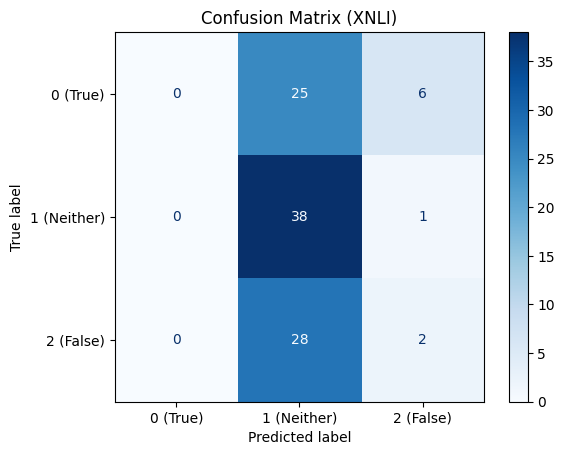

TypeError: 'module' object is not callable

In [92]:
analyze_predictions(os.path.join(output_path, "swa_xnli_prediction_dev.csv"))

## Distillation with MT

In [23]:
mt_raw

[{'ID': 'ID_290c7da3_test__mt_eng-hau',
  'task': 'translation',
  'instruction': "Your task is to do translation from English to Hausa. Your output must be the translation only. Don't output any explanation.",
  'input': "here's what you can expect during your visit.",
  'output': 'Lokacin zaicewa za ka samu manyi.',
  'lang': 'eng-swa',
  'prompt': "Your task is to do translation from English to Hausa. Your output must be the translation only. Don't output any explanation.\nhere's what you can expect during your visit."},
 {'ID': 'ID_fced026b_test__mt_eng-hau',
  'task': 'translation',
  'instruction': "Your task is to do translation from English to Hausa. Your output must be the translation only. Don't output any explanation.",
  'input': 'i agreed to."',
  'output': 'Na yaba masa.',
  'lang': 'eng-swa',
  'prompt': 'Your task is to do translation from English to Hausa. Your output must be the translation only. Don\'t output any explanation.\ni agreed to."'},
 {'ID': 'ID_764be3cd_te

In [16]:
from transformers import AutoConfig
cfg = AutoConfig.from_pretrained("lelapa/InkubaLM-0.4B")
print(cfg.architectures)


['LlamaForCausalLM']


In [35]:
from transformers import (
    Trainer, TrainingArguments, DataCollatorForLanguageModeling,
    AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig
)
from peft import get_peft_model, LoraConfig
from datasets import Dataset as HFDataset
import torch

# -------- Load Inkuba + LoRA --------
def load_lora_model(model_name="lelapa/InkubaLM-0.4B"):
    bnb_config = BitsAndBytesConfig(
        load_in_4bit=True,
        bnb_4bit_use_double_quant=True,
        bnb_4bit_quant_type="nf4",
        bnb_4bit_compute_dtype=torch.bfloat16,
    )

    tokenizer = AutoTokenizer.from_pretrained(model_name, use_fast=True)
    if tokenizer.pad_token is None:
        tokenizer.pad_token = tokenizer.eos_token

    model = AutoModelForCausalLM.from_pretrained(
        model_name,
        quantization_config=bnb_config,
        device_map="auto"
    )

    lora_config = LoraConfig(
        r=8,
        lora_alpha=16,
        target_modules=["q_proj", "v_proj"],
        lora_dropout=0.05,
        bias="none",
        task_type="CAUSAL_LM"
    )

    model = get_peft_model(model, lora_config)
    model.print_trainable_parameters()
    return model, tokenizer

# -------- Format prompt for causal LM --------
def preprocess_causal(example):
    prompt = example['prompt'].strip()
    output = example['output'].strip()
    full_prompt = f"{prompt}\n### Response: {output}"

    tokenized = tokenizer(
        full_prompt,
        max_length=512,
        truncation=True,
        padding="max_length"
    )
    tokenized["labels"] = tokenized["input_ids"].copy()  # CLM objective
    return tokenized

# -------- Load your dataset (replace mt_raw) --------
hf_dataset = HFDataset.from_list(mt_raw)  # 👈 your list of {"prompt", "output"}

# -------- Load model & tokenize data --------
model, tokenizer = load_lora_model()
tokenized = hf_dataset.map(preprocess_causal, remove_columns=hf_dataset.column_names)

# -------- Training setup --------
training_args = TrainingArguments(
    output_dir="./mt_finetune_inkuba",
    per_device_train_batch_size=2,
    num_train_epochs=20,
    learning_rate=2e-5,  # 👈 lowered LR
    gradient_accumulation_steps=2,
    logging_steps=5,
    save_steps=50,
    evaluation_strategy="no",
    report_to="none",
    remove_unused_columns=False,
    logging_dir="./logs",
)

collator = DataCollatorForLanguageModeling(tokenizer=tokenizer, mlm=False)

# -------- Train with default Trainer --------
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized,
    data_collator=collator,
    tokenizer=tokenizer,
)

trainer.train()

# -------- Save the fine-tuned model --------
model.save_pretrained("./mt_finetune_inkuba")
tokenizer.save_pretrained("./mt_finetune_inkuba")



trainable params: 524,288 || all params: 664,684,544 || trainable%: 0.0789


Map:   0%|          | 0/300 [00:00<?, ? examples/s]

/usr/local/lib/python3.11/dist-packages/transformers/training_args.py:1611: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(
<ipython-input-35-27824185884f>:81: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(
No label_names provided for model class `PeftModelForCausalLM`. Since `PeftModel` hides base models input arguments, if label_names is not given, label_names can't be set automatically within `Trainer`. Note that empty label_names list will be used instead.


Step,Training Loss
5,5.834700
10,5.958200
15,5.523300
20,5.824600
25,5.839600
30,5.898600
35,5.689200
40,5.499500
45,5.466000
50,5.612100


('./mt_finetune_inkuba/tokenizer_config.json',
 './mt_finetune_inkuba/special_tokens_map.json',
 './mt_finetune_inkuba/tokenizer.model',
 './mt_finetune_inkuba/added_tokens.json',
 './mt_finetune_inkuba/tokenizer.json')

## Run inference using mt_model

In [44]:
mt_df = pd.read_parquet("hf://datasets/lelapa/MTTrain/data/train-00000-of-00001.parquet")
hau_mt_df = mt_df.loc[mt_df['langs'] == 'eng-hau']
swa_mt_df = mt_df.loc[mt_df['langs'] == 'eng-swa']
hau_mt_dset = Dataset.from_pandas(hau_mt_df)
swa_mt_dset = Dataset.from_pandas(swa_mt_df)


In [93]:
import os
output_path = "/content/drive/MyDrive/InkubaLM-Challenge/Output/distillation"
os.makedirs(output_path, exist_ok=True)

print(os.path.exists(output_path))  # Should return True
print(output_path)
print(os.listdir(output_path))

True
/content/drive/MyDrive/InkubaLM-Challenge/Output/distillation
['hau_sentiment_prediction_dev.csv', 'hau_mt_prediction_dev.csv', 'swa_xnli_prediction_dev.csv', 'swa_sentiment_prediction_dev.csv', 'swa_mt_prediction_dev.csv', 'hau_xnli_prediction_dev.csv']


In [51]:
BASE_PROMPT = "{}\n### Response:"
task_instruction = "Your task is to do translation from English to Hausa. Your output must be the translation only. Don't output any explanation."
main(
    model=model,
    tokenizer=tokenizer,
    BASE_PROMPT="{}\n### Response:",
    task_instruction=task_instruction,
    dataset=hau_mt_dset,  # must include fields: instruction, inputs, output, ID, task="mmt"
    csv_file_path=os.path.join(output_path, "hau_mt_prediction_dev.csv"),
    custom_instruct=False,
    sample_size=100,
    max_new_tokens=40,
    temperature=0.7
)


Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for o

In [52]:
BASE_PROMPT = "{}\n### Response:"
task_instruction = "Your task is to do translation from English to Swahili. Your output must be the translation only. Don't output any explanation."
main(
    model=model,
    tokenizer=tokenizer,
    BASE_PROMPT="{}\n### Response:",
    task_instruction=task_instruction,
    dataset=swa_mt_dset,  # must include fields: instruction, inputs, output, ID, task="mmt"
    csv_file_path=os.path.join(output_path, "swa_mt_prediction_dev.csv"),
    custom_instruct=False,
    sample_size=100,
    max_new_tokens=40,
    temperature=0.7
)

Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for o

In [172]:
from collections import Counter
def process_likelihood(likelihood_str: str) -> List[float]:
    """
    Process a likelihood string to clean and convert it to a list of floats.
    """
    # Clean the string to remove unwanted characters
    clean_str = (
        likelihood_str.replace("tensor(", "").replace(")", "").strip()
        .replace("[[", "").replace("]]", "").strip()
        .replace(" device='cuda:0'", "").replace(" dtype=torch.float16", "").strip()
        .replace("tensor", "").strip()
    )

    # Remove any empty strings caused by extra commas
    clean_str = clean_str.replace(",,", ",")  # Remove duplicate commas if they exist

    # Convert to a list of floats
    likelihood = [
        float(x) for x in clean_str.split(",") if x.strip()
    ]  # Ensure non-empty strings are converted
    return likelihood

import math

def process_likelihood(likelihood_str):
    if likelihood_str is None or (isinstance(likelihood_str, float) and math.isnan(likelihood_str)):
        return None  # or return some default

    likelihood_str = str(likelihood_str)
    clean_str = (
        likelihood_str.replace("tensor(", "")
        .replace(")", "")
        .replace("[[", "")
        .replace("]]", "")
        .replace(" device='cuda:0'", "")
        .replace(" dtype=torch.float16", "")
        .strip()
    )
    return clean_str


def create_submission(output_path, test_flag: bool):
    """
    Creates submission files based on the provided test_flag.

    Args:
    test_flag (bool): If True, creates a test submission file; otherwise, creates a final submission file.
    """
    if test_flag:
        try:
            df1 = pd.read_csv(os.path.join(
                output_path,
                "hau_sentiment_prediction_dev.csv")
                 )
            df2 = pd.read_csv(os.path.join(
                output_path,
                "swa_sentiment_prediction_dev.csv")
            )
            df3 = pd.read_csv(os.path.join(
                output_path,
                "hau_mt_prediction_dev.csv")
                             )
            df4 = pd.read_csv(os.path.join(
                output_path,
                "swa_mt_prediction_dev.csv"))
            df5 = pd.read_csv(os.path.join(
                output_path,
                "hau_xnli_prediction_dev.csv"))
            df6 = pd.read_csv(os.path.join(
                output_path,
                "swa_xnli_prediction_dev.csv"))
        except FileNotFoundError as e:
            print(
                "Seems you have not completed all the tasks, please complete all the tasks before attempting to create your submission file"
            )
            raise e
    else:
        filename = "submission.csv"
        try:
            df1 = pd.read_csv(os.path.join(
                output_path,
                "hau_sentiment_prediction.csv"))
            df2 = pd.read_csv(os.path.join(
                output_path,
                "swa_sentiment_prediction.csv"))
            df3 = pd.read_csv(os.path.join(
                output_path,
                "hau_mt_prediction.csv"))
            df4 = pd.read_csv(os.path.join(
                output_path,
                "swa_mt_prediction.csv"))
            df5 = pd.read_csv(os.path.join(
                output_path,
                "hau_xnli_prediction.csv"))
            df6 = pd.read_csv(os.path.join(
                output_path,
                "swa_xnli_prediction.csv"))
        except FileNotFoundError as e:
            print(
                "Seems you have not completed all the tasks, please complete all the tasks before attempting to create your submission file"
            )
            raise e

    # Combine and process data
    resmt = pd.concat([df3, df4], ignore_index=True)
    res_log = pd.concat([df1, df2, df5, df6], ignore_index=True)
    res_log.drop(columns=["Response"], inplace=True)
    res_log.rename(columns={"Log-Likelihood": "Response"}, inplace=True)
    res = pd.concat([res_log, resmt], ignore_index=True)

    def process_row(row):
        if "xnli" in row["ID"] or "sent" in row["ID"]:
            likelihoods = process_likelihood(row["Response"])
            predicted_label = np.argmax(likelihoods)
            return predicted_label
        return row["Response"]  # Default for other cases

    # Update the Response column in-place
    res["Response"] = res.apply(process_row, axis=1)

    if test_flag:
        filename = os.path.join(
                output_path,
                "submission_test.csv")
        # Save the submission file
        submission = res[["ID", "Response", "Targets"]]
        submission.to_csv(filename, index=False)
    else:
        filename = os.path.join(
                output_path,
                "submission.csv")
        # Save the submission file
        submission = res[["ID", "Response"]]
        submission.to_csv(filename, index=False)
    return submission

def evaluate_zindi_by_language(df):
    from collections import defaultdict, Counter
    import numpy as np

    results = defaultdict(lambda: defaultdict(list))  # results[task][lang] = [(true, pred), ...]
    chrfs_scores = defaultdict(list)

    for _, row in df.iterrows():
        ID = row["ID"].lower()

        # --- Task detection ---
        if "sentiment" in ID or "sent" in ID:
            task = "sent"
        elif "xnli" in ID or "afrixnli" in ID:
            task = "xnli"
        elif "mt" in ID:
            task = "mt"
        else:
            continue  # skip unknown tasks

        # --- Language detection ---
        if any(x in ID for x in ["swahili", "swa", "eng-swa"]):
            lang = "swahili"
        elif any(x in ID for x in ["hausa", "hau", "eng-hau"]):
            lang = "hausa"
        else:
            lang = "unknown"

        # --- Scoring logic ---
        if task == "sent":
            labels = {
                "swahili": ["Chanya", "Wastani", "Hasi"],
                "hausa": ["Kyakkyawa", "Tsaka-tsaki", "Korau"]
            }.get(lang, [])
            if not labels:
                continue
            label_to_id = {label.lower(): i for i, label in enumerate(labels)}
            true = label_to_id.get(row["Targets"].strip().lower(), -1)
            pred = int(row["Response"])
            if true != -1:
                results[task][lang].append((true, pred))

        elif task == "xnli":
            try:
                true = int(row["Targets"])
                pred = int(row["Response"])
                results[task][lang].append((true, pred))
            except:
                continue  # skip rows with invalid labels

        elif task == "mt":
            ref = row["Targets"]
            hyp = row["Response"]
            chrfs = chrF(reference=ref, hypothesis=hyp)
            chrfs_scores[lang].append(chrfs)

    # --- Aggregation ---
    report = {}
    for task in results:
        for lang in results[task]:
            y_true, y_pred = zip(*results[task][lang])
            f1 = calculate_f1(np.array(y_true), np.array(y_pred), num_classes=3)
            report[f"{task}_{lang}"] = round(f1, 4)

    for lang in chrfs_scores:
        avg_chrfs = np.mean(chrfs_scores[lang])
        report[f"mt_{lang}"] = round(avg_chrfs, 4)

    # --- Zindi score ---
    zindi_score = np.mean(list(report.values()))
    report["zindi_score"] = round(zindi_score, 4)

    return report


# From scratch implementation of chrf
def get_char_ngrams(sentence, n):
    """Generate character n-grams from a sentence."""
    sentence = sentence.replace(" ", "")  # Remove spaces for chrF
    return [sentence[i : i + n] for i in range(len(sentence) - n + 1)]


def precision_recall(reference, hypothesis, n):
    """Calculate precision and recall for character n-grams."""
    ref_ngrams = get_char_ngrams(reference, n)
    hyp_ngrams = get_char_ngrams(hypothesis, n)

    ref_count = Counter(ref_ngrams)
    hyp_count = Counter(hyp_ngrams)

    common_ngrams = ref_count & hyp_count
    true_positives = sum(common_ngrams.values())

    precision = true_positives / max(len(hyp_ngrams), 1)
    recall = true_positives / max(len(ref_ngrams), 1)

    return precision, recall


def f_score(precision, recall, beta=1):
    """Calculate the F1 score."""
    if precision + recall == 0:
        return 0.0
    return (1 + beta**2) * (precision * recall) / (beta**2 * precision + recall)


def chrF(reference, hypothesis, max_n=6, beta=2):
    """Calculate the chrF score from scratch."""
    precisions = []
    recalls = []

    for n in range(1, max_n + 1):
        precision, recall = precision_recall(reference, hypothesis, n)
        precisions.append(precision)
        recalls.append(recall)

    avg_precision = sum(precisions) / max_n
    avg_recall = sum(recalls) / max_n

    return f_score(avg_precision, avg_recall, beta)


# From scratch implementation f1score 3 class
def calculate_f1(true_labels, pred_labels, num_classes):
    f1_scores = []

    for i in range(num_classes):
        TP = np.sum((true_labels == i) & (pred_labels == i))  # True Positives
        FP = np.sum((true_labels != i) & (pred_labels == i))  # False Positives
        FN = np.sum((true_labels == i) & (pred_labels != i))  # False Negatives

        precision = TP / (TP + FP) if (TP + FP) > 0 else 0
        recall = TP / (TP + FN) if (TP + FN) > 0 else 0

        # Calculate F1 score
        f1 = (
            2 * (precision * recall) / (precision + recall)
            if (precision + recall) > 0
            else 0
        )
        f1_scores.append(f1)

    macro_f1 = np.mean(f1_scores)

    return macro_f1


In [173]:
os.listdir(output_path)

['hau_sentiment_prediction_dev.csv',
 'swa_sent_prediction_dev.csv',
 'hau_mt_prediction_dev.csv',
 'hau_sent_prediction_dev.csv',
 'swa_xnli_prediction_dev.csv',
 'swa_sentiment_prediction_dev.csv',
 'swa_mt_prediction_dev.csv',
 'submission_test.csv',
 'hau_xnli_prediction_dev.csv']

In [163]:
test = pd.read_csv(os.path.join(output_path, 'hau_sentiment_prediction_dev.csv'))

In [176]:
test['Response']

,Response
0,Kyakkyawa
1,Kyakkyawa
2,Kyakkyawa
3,Kyakkyawa
4,Kyakkyawa
...,...
95,Kyakkyawa
96,Kyakkyawa
97,Kyakkyawa
98,Kyakkyawa


In [174]:
score_test = create_submission(output_path=output_path, test_flag=True)